# ONERA 468 CRM Data Exploration

End-to-end notebook for the ONERA 468 CRM Codabench challenge.
Covers: data loading, train/test split visualization, 3-D density field
rendering, KNN baseline training, extended error metrics, and residual
KL-divergence analysis.

## 1. Imports

In [6]:
#srun --account=tau --partition=gpu-best --nodes=1 --ntasks=1 --cpus-per-task=10 --gres=gpu:1 --mem=64G --time=18:00:00 --pty bash

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import cKDTree
from scipy.stats import norm, entropy
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


## 2. Global Constants

Column indices into the 9-feature input array and mesh-level constants
shared across all analysis sections.

In [2]:
nwallp           = 260774   # wall points per simulation
COL_MINF         = 6        # Mach number column
COL_AOA          = 7        # angle of attack column
COL_PI           = 8        # tunnel pressure ratio column
GRAD_PERCENTILE  = 95       # percentile threshold for shock-zone detection
SHOCK_NEIGHBOR_K = 6        # k-NN order for local gradient estimation
OUTPUT_DIR       = '../output/'
DATA_DIR         = '/data/tau/iceberg_1/shared/ochabane/FILES_RHO_ALL_POINTS_reduitfloat32/'


## 3. Train/Test Split — CSV Merge

The full-file CSV contains all 468 simulations with their flow parameters
and scores. The split CSV assigns each simulation to train or test based
on a Mach-stratified strategy. Here we merge the `Train` label from the
split CSV into the full-file CSV and save the result.

In [3]:
df_full = pd.read_csv(
    '/data/tau/iceberg_1/shared/ochabane/FILES_RHO_ALL_POINTS_reduitfloat32/'
    'fullfiles_PiMinfAoA_with_scores.csv'
)
df_split = pd.read_csv(
    '/data/tau/iceberg_1/shared/ochabane/FILES_RHO_ALL_POINTS_reduitfloat32/'
    'traintest_splitting1_MinfAoAPi_with_scores.csv'
)

print('df_full  Train (before drop):', df_full['Train'].value_counts().to_dict())
print('df_split Train              :', df_split['Train'].value_counts().to_dict())

df_full = df_full.drop(columns=['Train'])
df_merged = df_full.merge(
    df_split[['Pi', 'Mach', 'AoA', 'Train']],
    on=['Pi', 'Mach', 'AoA'],
    how='left'
)

print('\ndf_merged shape:', df_merged.shape)
print('NaN in Train   :', df_merged['Train'].isna().sum())
assert len(df_merged) == len(df_full), \
    f'Length mismatch: {len(df_full)} -> {len(df_merged)}'
print('Length OK :', len(df_merged))
print('Train after merge:', df_merged['Train'].value_counts().to_dict())

df_merged.to_csv(
    '/data/tau/iceberg_1/shared/ochabane/FILES_RHO_ALL_POINTS_reduitfloat32/'
    'f.csv',
    index=False
)
print('\nFile saved.')


df_full  Train (before drop): {True: 468}
df_split Train              : {True: 312, False: 156}

df_merged shape: (468, 10)
NaN in Train   : 0
Length OK : 468
Train after merge: {True: 312, False: 156}

File saved.


## 5. 3-D Density Field Visualization

Renders the normalised density field (rho/rho_inf) on the CRM aircraft
surface mesh for a single simulation. The color scale is clipped at the
3rd and 97th percentiles to avoid distortion from outlier values.
Edit the four user-input variables below to switch simulations.

## 6. KNN Baseline — Phase 1 & 2 Evaluation

Loads train and test arrays for both Codabench phases, trains a
5-NN regressor on (Mach, AoA, Pi) condition vectors, predicts the
density field, and plots the worst-case condition for each phase.
The weighted-relMAE metric (wrMAE) down-weights simulations with
|AoA| >= 10 deg by 0.5.

Loading data...


Training KNN...
Predicting phase 1...
Predicting phase 2...

Phase 1 -- worst condition index: 12  wrMAE: 0.0851
Phase 2 -- worst condition index: 60  wrMAE: 0.1342
Saved: worst_condition_Phase_1.png


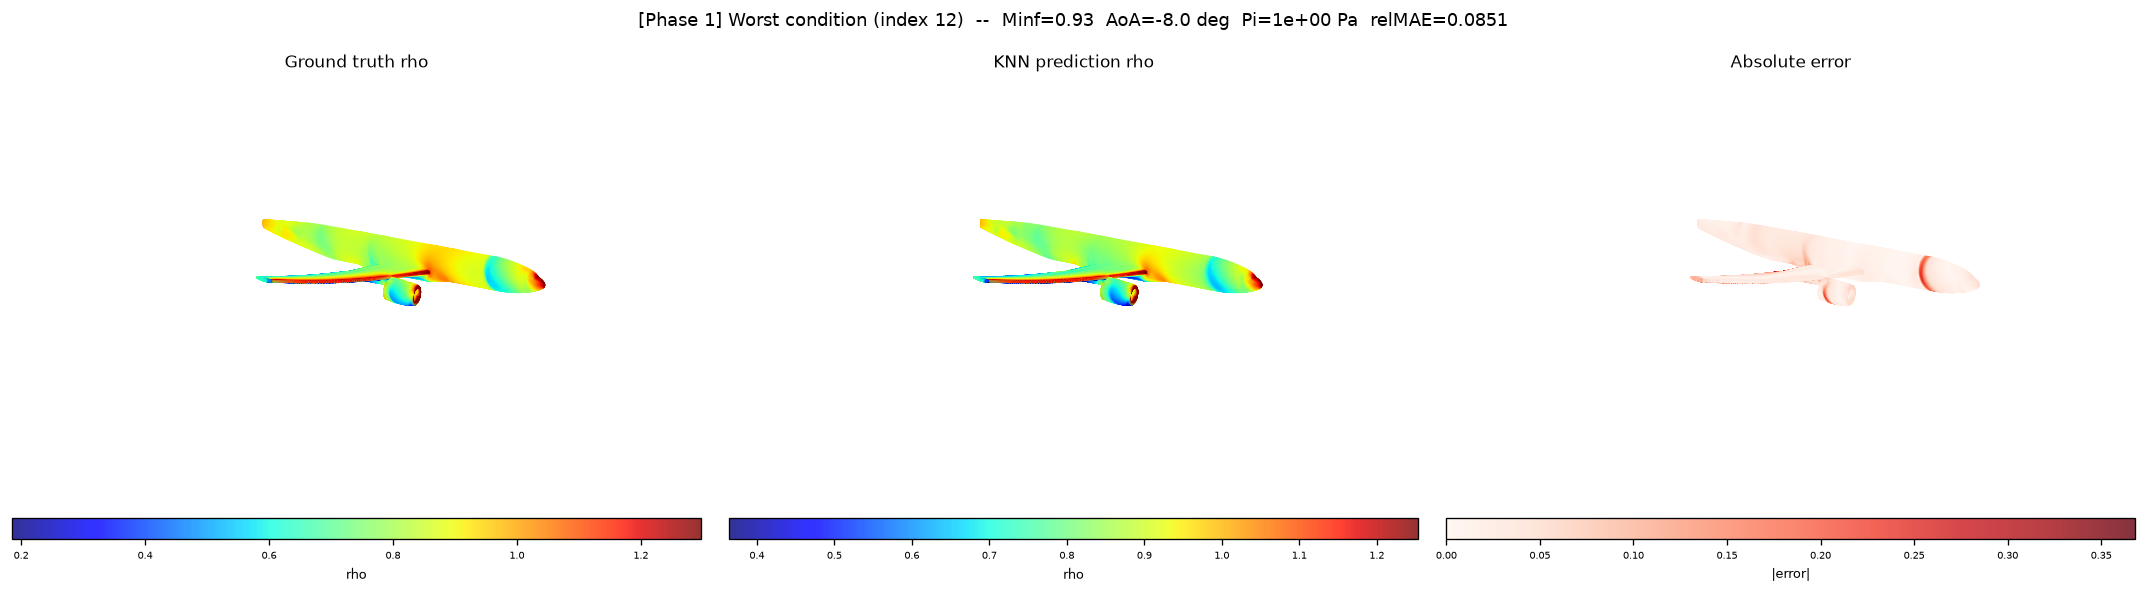

Saved: worst_condition_Phase_2.png


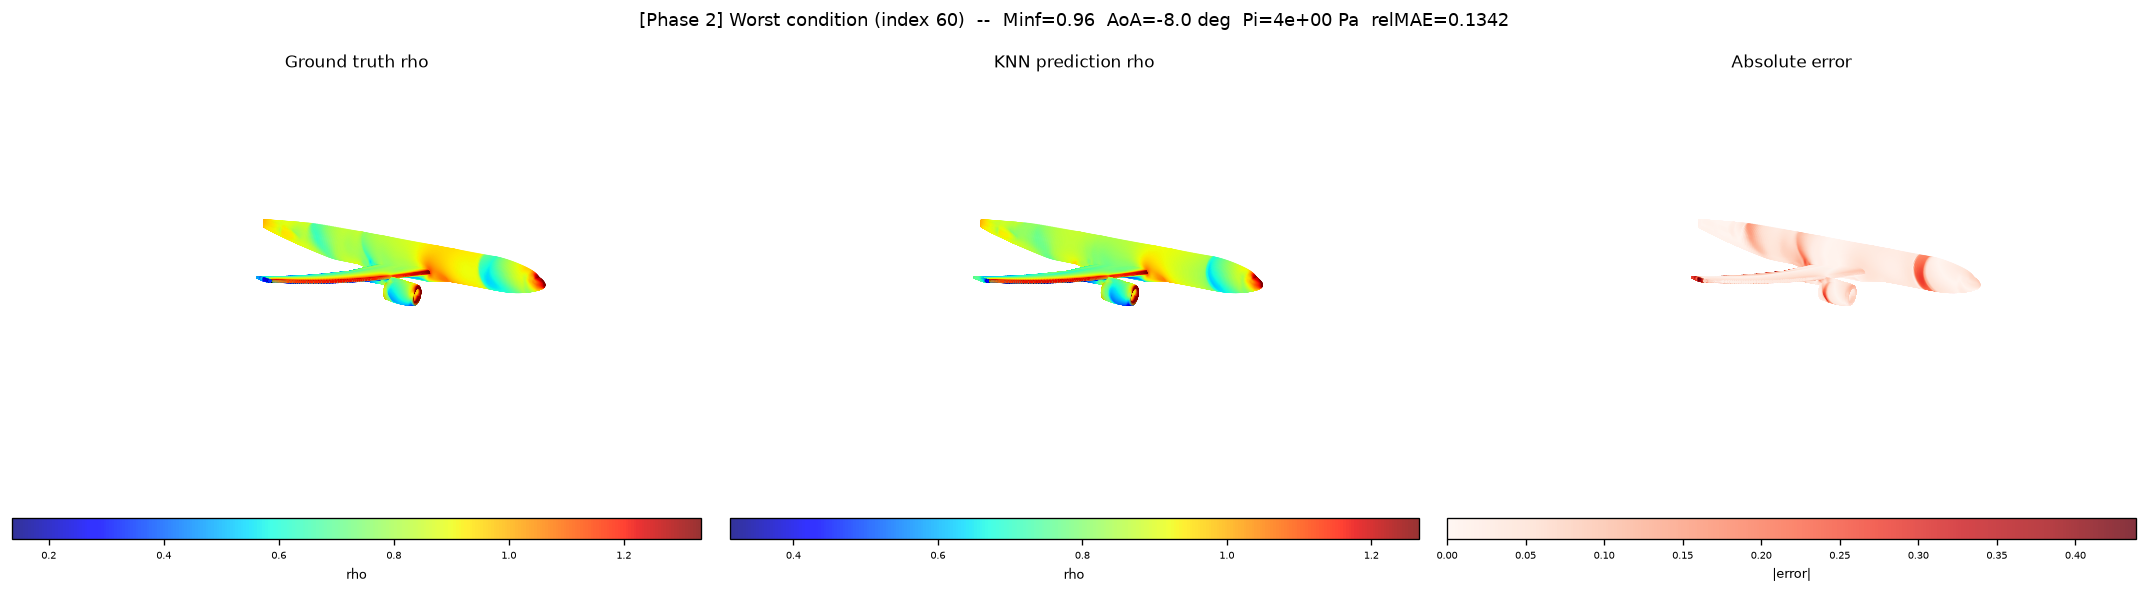

In [9]:
print('Loading data...')
X_train = np.load(DATA_DIR + 'train_data.npy')
y_train = np.load(DATA_DIR + 'train_labels.npy')[:, 0]
X_test1 = np.load(DATA_DIR + 'test_phase1_data.npy')
y_test1 = np.load(DATA_DIR+'test_phase1_labels.npy')[:, 0]
X_test2 = np.load(DATA_DIR + 'test_phase2_data.npy')
y_test2 = np.load(DATA_DIR+'test_phase2_labels.npy')[:, 0]

train_conds = X_train[::nwallp, COL_MINF:COL_PI+1]
test1_conds = X_test1[::nwallp, COL_MINF:COL_PI+1]
test2_conds = X_test2[::nwallp, COL_MINF:COL_PI+1]

n_train = X_train.shape[0] // nwallp
n_test1 = X_test1.shape[0] // nwallp
n_test2 = X_test2.shape[0] // nwallp

test1_weights = np.where(np.abs(test1_conds[:, 1]) < 10.0, 1.0, 0.5)
test2_weights = np.where(np.abs(test2_conds[:, 1]) < 10.0, 1.0, 0.5)

scaler         = StandardScaler()
train_conds_sc = scaler.fit_transform(train_conds)
test1_conds_sc = scaler.transform(test1_conds)
test2_conds_sc = scaler.transform(test2_conds)

print('Training KNN...')
knn = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn.fit(train_conds_sc, y_train.reshape(n_train, nwallp))

print('Predicting phase 1...')
y_pred1 = knn.predict(test1_conds_sc).reshape(-1)
print('Predicting phase 2...')
y_pred2 = knn.predict(test2_conds_sc).reshape(-1)


def compute_wrMAE(y, y_pred, weights, nwallp):
    """Worst-case weighted relative MAE across simulations with weight=1.0."""
    relMAE_list, idx_list = [], []
    for i in range(len(weights)):
        if weights[i] < 1.0:
            continue
        yc    = y    [i * nwallp:(i + 1) * nwallp]
        yhatc = y_pred[i * nwallp:(i + 1) * nwallp]
        relMAE_list.append(np.mean(np.abs(yc - yhatc)) / np.mean(np.abs(yc)))
        idx_list.append(i)
    iworst = idx_list[int(np.argmax(relMAE_list))]
    return iworst, float(np.max(relMAE_list)), np.array(relMAE_list), idx_list


iworst1, wrMAE1, relMAEs1, idxs1 = compute_wrMAE(y_test1, y_pred1, test1_weights, nwallp)
iworst2, wrMAE2, relMAEs2, idxs2 = compute_wrMAE(y_test2, y_pred2, test2_weights, nwallp)

print(f'\nPhase 1 -- worst condition index: {iworst1}  wrMAE: {wrMAE1:.4f}')
print(f'Phase 2 -- worst condition index: {iworst2}  wrMAE: {wrMAE2:.4f}')


def plot_condition(iworst, X_test, y_test, y_pred, nwallp, wrMAE, phase_label):
    """3-D scatter of ground truth, prediction and absolute error for one simulation."""
    X_worst    = X_test [iworst * nwallp:(iworst + 1) * nwallp]
    y_worst    = y_test [iworst * nwallp:(iworst + 1) * nwallp]
    yhat_worst = y_pred [iworst * nwallp:(iworst + 1) * nwallp]

    Minf = X_worst[0, COL_MINF]
    AoA  = X_worst[0, COL_AOA]
    Pi   = X_worst[0, COL_PI]

    X_coord = X_worst[:, 0]
    Y_coord = X_worst[:, 1]
    Z_coord = X_worst[:, 2]
    error   = np.abs(y_worst - yhat_worst)

    def _scale(field):
        f03, f50, f97 = np.percentile(field, [3., 50., 97.])
        slopem = (f50 - f03) / 0.47
        slopep = (f97 - f50) / 0.47
        return max(0., f50 - 0.6 * slopem), f50 + 0.6 * slopep

    fields = [y_worst, yhat_worst, error]
    titles = ['Ground truth rho', 'KNN prediction rho', 'Absolute error']
    cmaps  = ['jet', 'jet', 'Reds']

    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[{phase_label}] Worst condition (index {iworst})  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.0e} Pa  relMAE={wrMAE:.4f}',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(fields, titles, cmaps)):
        gs  = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax  = fig.add_subplot(gs[0, col], projection='3d')
        fmin, fmax = _scale(field)
        sca = ax.scatter3D(X_coord, Y_coord, Z_coord,
                           c=field, vmin=fmin, vmax=fmax,
                           cmap=cmap, s=0.3, alpha=0.8)
        ax.view_init(elev=20, azim=120)
        ax.set_xlim(X_coord.min() - 5.0, X_coord.max() + 5.0)
        ax.set_ylim(Y_coord.min() - 5.0, Y_coord.max() + 5.0)
        ax.set_zlim(Z_coord.min(), Z_coord.max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'worst_condition_{phase_label.replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


plot_condition(iworst1, X_test1, y_test1, y_pred1, nwallp, wrMAE1, 'Phase 1')
plot_condition(iworst2, X_test2, y_test2, y_pred2, nwallp, wrMAE2, 'Phase 2')


## 7. Extended Metrics — Random 80/20 Split

Re-trains the KNN on a random 80/20 simulation split (seed=42) and
computes a comprehensive set of diagnostic metrics:

- **Per-simulation R²** — global fit quality per condition.
- **wrMAE by component** — worst-case relMAE on fuselage / nacelle / pylon / wing.
- **Gradient-weighted MAE** — emphasises shock-prone regions.
- **Shock-zone MAE** — MAE restricted to top-5% gradient points.
- **wrMAE by Mach range** — breakdown by sub / transonic regime.

Results are printed as a summary table and displayed as a 6-panel dashboard.

In [4]:
X = np.load(DATA_DIR + 'X9_ALL_POINT_fl32.npy')
y = np.load(DATA_DIR + 'RHO_ALL_POINT_fl32.npy')[:, 0]

component_labels = np.load(DATA_DIR + 'component_labels_unique.npy')
with open(DATA_DIR + 'component_map.json') as f:
    component_map = {int(k): v for k, v in json.load(f).items()}

n_sims = X.shape[0] // nwallp
conds  = X[::nwallp, COL_MINF:COL_PI+1]
coords = X[:nwallp, :3]

train_sims, test_sims = train_test_split(np.arange(n_sims), test_size=0.2, random_state=42)

X_train = np.concatenate([X[i*nwallp:(i+1)*nwallp] for i in train_sims])
y_train = np.concatenate([y[i*nwallp:(i+1)*nwallp] for i in train_sims])
X_test  = np.concatenate([X[i*nwallp:(i+1)*nwallp] for i in test_sims])
y_test  = np.concatenate([y[i*nwallp:(i+1)*nwallp] for i in test_sims])

scaler         = StandardScaler().fit(conds[train_sims])
train_conds_sc = scaler.transform(conds[train_sims])
test_conds_sc  = scaler.transform(conds[test_sims])

n_test      = len(test_sims)
weights_sim = np.where(np.abs(conds[test_sims, COL_AOA - COL_MINF]) < 10.0, 1.0, 0.5)


print(f'Train: {len(train_sims)} sims -- Test: {n_test} sims')
knn = KNeighborsRegressor(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn.fit(train_conds_sc, y_train.reshape(len(train_sims), nwallp))
y_pred = knn.predict(test_conds_sc).reshape(-1)
print('Predictions done.')


def fast_gradient(y_field, idxs_sh, dists_sh):
    """Local gradient magnitude using a pre-built shared k-NN tree."""
    grad = np.zeros(nwallp)
    for i in range(nwallp):
        nbr     = idxs_sh[i, 1:]
        d       = dists_sh[i, 1:] + 1e-12
        grad[i] = np.max(np.abs(y_field[nbr] - y_field[i]) / d)
    return grad


print('Pre-computing shared k-NN tree for gradient estimation...')
tree_shared        = cKDTree(coords)
dists_sh, idxs_sh = tree_shared.query(coords, k=SHOCK_NEIGHBOR_K + 1)

Y  = y_test.reshape(n_test, nwallp)
Yh = y_pred.reshape(n_test, nwallp)

r2_sims, gw_maes, shock_maes = [], [], []
comp_relMAEs = {v: [] for v in component_map.values()}
relMAEs_weighted, weighted_idx = [], []

print('Computing metrics per simulation...')
for i in range(n_test):
    yc    = Y[i]
    yhatc = Yh[i]
    err   = np.abs(yc - yhatc)

    ss_res = np.sum((yc - yhatc)**2)
    ss_tot = np.sum((yc - yc.mean())**2)
    r2_sims.append(1.0 - ss_res / (ss_tot + 1e-12))

    grad   = fast_gradient(yc, idxs_sh, dists_sh)
    w_grad = grad / (grad.mean() + 1e-12)
    gw_maes.append(float(np.mean(w_grad * err)))

    shock_mask = grad >= np.percentile(grad, GRAD_PERCENTILE)
    shock_maes.append(float(np.mean(err[shock_mask])) if shock_mask.any() else np.nan)

    if weights_sim[i] >= 1.0:
        relMAEs_weighted.append(float(np.mean(err) / (np.mean(np.abs(yc)) + 1e-12)))
        weighted_idx.append(i)
        for cid, cname in component_map.items():
            mask = component_labels == cid
            comp_relMAEs[cname].append(
                float(np.mean(err[mask]) / (np.mean(np.abs(yc[mask])) + 1e-12))
            )

r2_sims    = np.array(r2_sims)
gw_maes    = np.array(gw_maes)
shock_maes = np.array(shock_maes)
wrMAE      = float(np.max(relMAEs_weighted))
iworst_loc = int(np.argmax(relMAEs_weighted))
iworst_sim = test_sims[weighted_idx[iworst_loc]]

machs_test = conds[test_sims, 0]
aoas_test  = conds[test_sims, 1]

mach_bins    = [(0.0, 0.50, 'low-sub'), (0.50, 0.75, 'sub'),
                (0.75, 0.90, 'low-transonic'), (0.90, 1.00, 'high-transonic')]
mach_results = {}
for lo, hi, label in mach_bins:
    idx  = [j for j, mi in enumerate(machs_test)
            if lo <= mi < hi and weights_sim[j] >= 1.0]
    vals = [relMAEs_weighted[weighted_idx.index(j)] for j in idx if j in weighted_idx]
    if vals:
        mach_results[label] = {
            'wrMAE'  : float(np.max(vals)),
            'meanMAE': float(np.mean(vals)),
            'n_sims' : len(vals),
        }

print(f'\n{"─"*55}')
print(f'  SUMMARY -- random split (80/20, seed=42)')
print(f'{"─"*55}')
print(f'  Train sims : {len(train_sims)}   Test sims : {n_test}')
print(f'  Per-sim R2        mean={r2_sims.mean():.4f}  min={r2_sims.min():.4f}  p05={np.percentile(r2_sims,5):.4f}')
print(f'  wrMAE             {wrMAE:.4f}  (sim {iworst_sim}  Mach={conds[iworst_sim,0]:.2f}  AoA={conds[iworst_sim,1]:.1f} deg)')
print(f'  Grad-weighted MAE mean={np.nanmean(gw_maes):.4f}  max={np.nanmax(gw_maes):.4f}')
print(f'  Shock-zone MAE    mean={np.nanmean(shock_maes):.4f}  max={np.nanmax(shock_maes):.4f}')
print(f'\n  wrMAE by component:')
for cname, vals in comp_relMAEs.items():
    print(f'    {cname:<12}  wrMAE={max(vals):.4f}  mean={np.mean(vals):.4f}')
print(f'\n  wrMAE by Mach range:')
for rng, res in mach_results.items():
    print(f'    {rng:<18}  wrMAE={res["wrMAE"]:.4f}  mean={res["meanMAE"]:.4f}  n={res["n_sims"]}')
print(f'{"─"*55}')



Train: 374 sims -- Test: 94 sims
Predictions done.
Pre-computing shared k-NN tree for gradient estimation...
Computing metrics per simulation...

───────────────────────────────────────────────────────
  SUMMARY -- random split (80/20, seed=42)
───────────────────────────────────────────────────────
  Train sims : 374   Test sims : 94
  Per-sim R2        mean=0.9349  min=0.3175  p05=0.7999
  wrMAE             0.0848  (sim 311  Mach=0.96  AoA=8.0 deg)
  Grad-weighted MAE mean=0.0262  max=0.1535
  Shock-zone MAE    mean=0.0264  max=0.1313

  wrMAE by component:
    fuselage      wrMAE=0.0363  mean=0.0101
    nacelle       wrMAE=0.0295  mean=0.0109
    pylon         wrMAE=0.1587  mean=0.0288
    wing          wrMAE=0.2102  mean=0.0367

  wrMAE by Mach range:
    low-sub             wrMAE=0.0077  mean=0.0077  n=1
    sub                 wrMAE=0.0177  mean=0.0123  n=7
    low-transonic       wrMAE=0.0270  mean=0.0139  n=45
    high-transonic      wrMAE=0.0848  mean=0.0372  n=29
────────────

## 8. Residual KL-Divergence Metrics

Measures how close the residual distribution is to a narrow reference
Gaussian N(0, sigma_ref) -- a proxy for Dirac(0), i.e. perfect prediction.
The score = exp(-KL) lies in (0, 1]; higher is better.

Two helpers are defined:
- `residual_kl_dirac`: works on normalised residuals (eps / sigma_y),
  with sigma_ref fixed at 0.01 in normalised units.
- `residual_kl_normal`: works on raw residuals, sigma_ref = 0.1 * sigma_y.

The analysis below uses `residual_kl_normal` per simulation and per component,
then prints a full breakdown and plots residual histograms for the worst
and median simulations.

In [5]:
def residual_kl_dirac(y_true, y_pred, sigma_ref_frac=0.01, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref is very small (proxy for Dirac(0)).
    Returns KL, score=exp(-KL), normalised bias and spread.
    """
    eps      = y_pred - y_true
    sigma_y  = y_true.std() + 1e-12
    eps_norm = eps / sigma_y
    sigma_ref = sigma_ref_frac

    bins = np.linspace(-5.0, 5.0, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps_norm, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref)
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(np.exp(-kl)),
            'bias': float(np.mean(eps_norm)), 'spread': float(np.std(eps_norm))}


def residual_kl_normal(y_true, y_pred, sigma_ref_frac=0.1, n_bins=200):
    """
    KL(p_eps || N(0, sigma_ref)) where sigma_ref = sigma_ref_frac * sigma_y.
    Returns KL, score=exp(-KL), normalised bias and spread.
    """
    eps       = y_pred - y_true
    sigma_y   = y_true.std() + 1e-12
    sigma_ref = sigma_ref_frac * sigma_y

    lim  = 5.0 * sigma_y
    bins = np.linspace(-lim, lim, n_bins + 1)
    dx   = bins[1] - bins[0]
    p, _ = np.histogram(eps, bins=bins, density=True)
    p    = np.clip(p * dx, 1e-10, None)
    p   /= p.sum()

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    q    = norm.pdf(bin_centers, loc=0.0, scale=sigma_ref) * dx
    q    = np.clip(q, 1e-10, None)
    q   /= q.sum()

    kl    = float(entropy(p, q))
    return {'kl': kl, 'score': float(np.exp(-kl)),
            'bias': float(np.mean(eps) / sigma_y), 'spread': float(np.std(eps) / sigma_y)}



  Residual KL-Normal metrics -- random split (80/20, seed=42)

  Global (all points):
    KL    mean=0.9635  max=3.9380  min=0.2086
    score mean=0.4755  min=0.0195  (higher=better)
    bias  mean=-0.0035  std=0.0787
    spread mean=0.1777  max=0.4640

  Global (pooled, all aircraft concatenated):
    KL    =0.7052
    score =0.4940  (higher=better)
    bias  =0.0139
    spread=0.2138

  Worst sim : 74  Mach=0.96  AoA=-4.0 deg  KL=0.2086  score=0.0195
  Best  sim : 53   Mach=0.93  AoA=-6.0 deg  KL=3.9380  score=0.8117

  Per component:
  component       mean KL     max KL  mean score   mean bias  mean spread
  ────────────  ─────────  ─────────  ──────────  ──────────  ───────────
  fuselage         1.1191    11.7436      0.4315     -0.0219       0.1372
  nacelle          0.5559     2.5473      0.6032     -0.0095       0.0825
  pylon            2.0032     7.8448      0.3290     -0.0025       0.2120
  wing             1.8063     9.3124      0.3539      0.0041       0.2354

  Worst sim

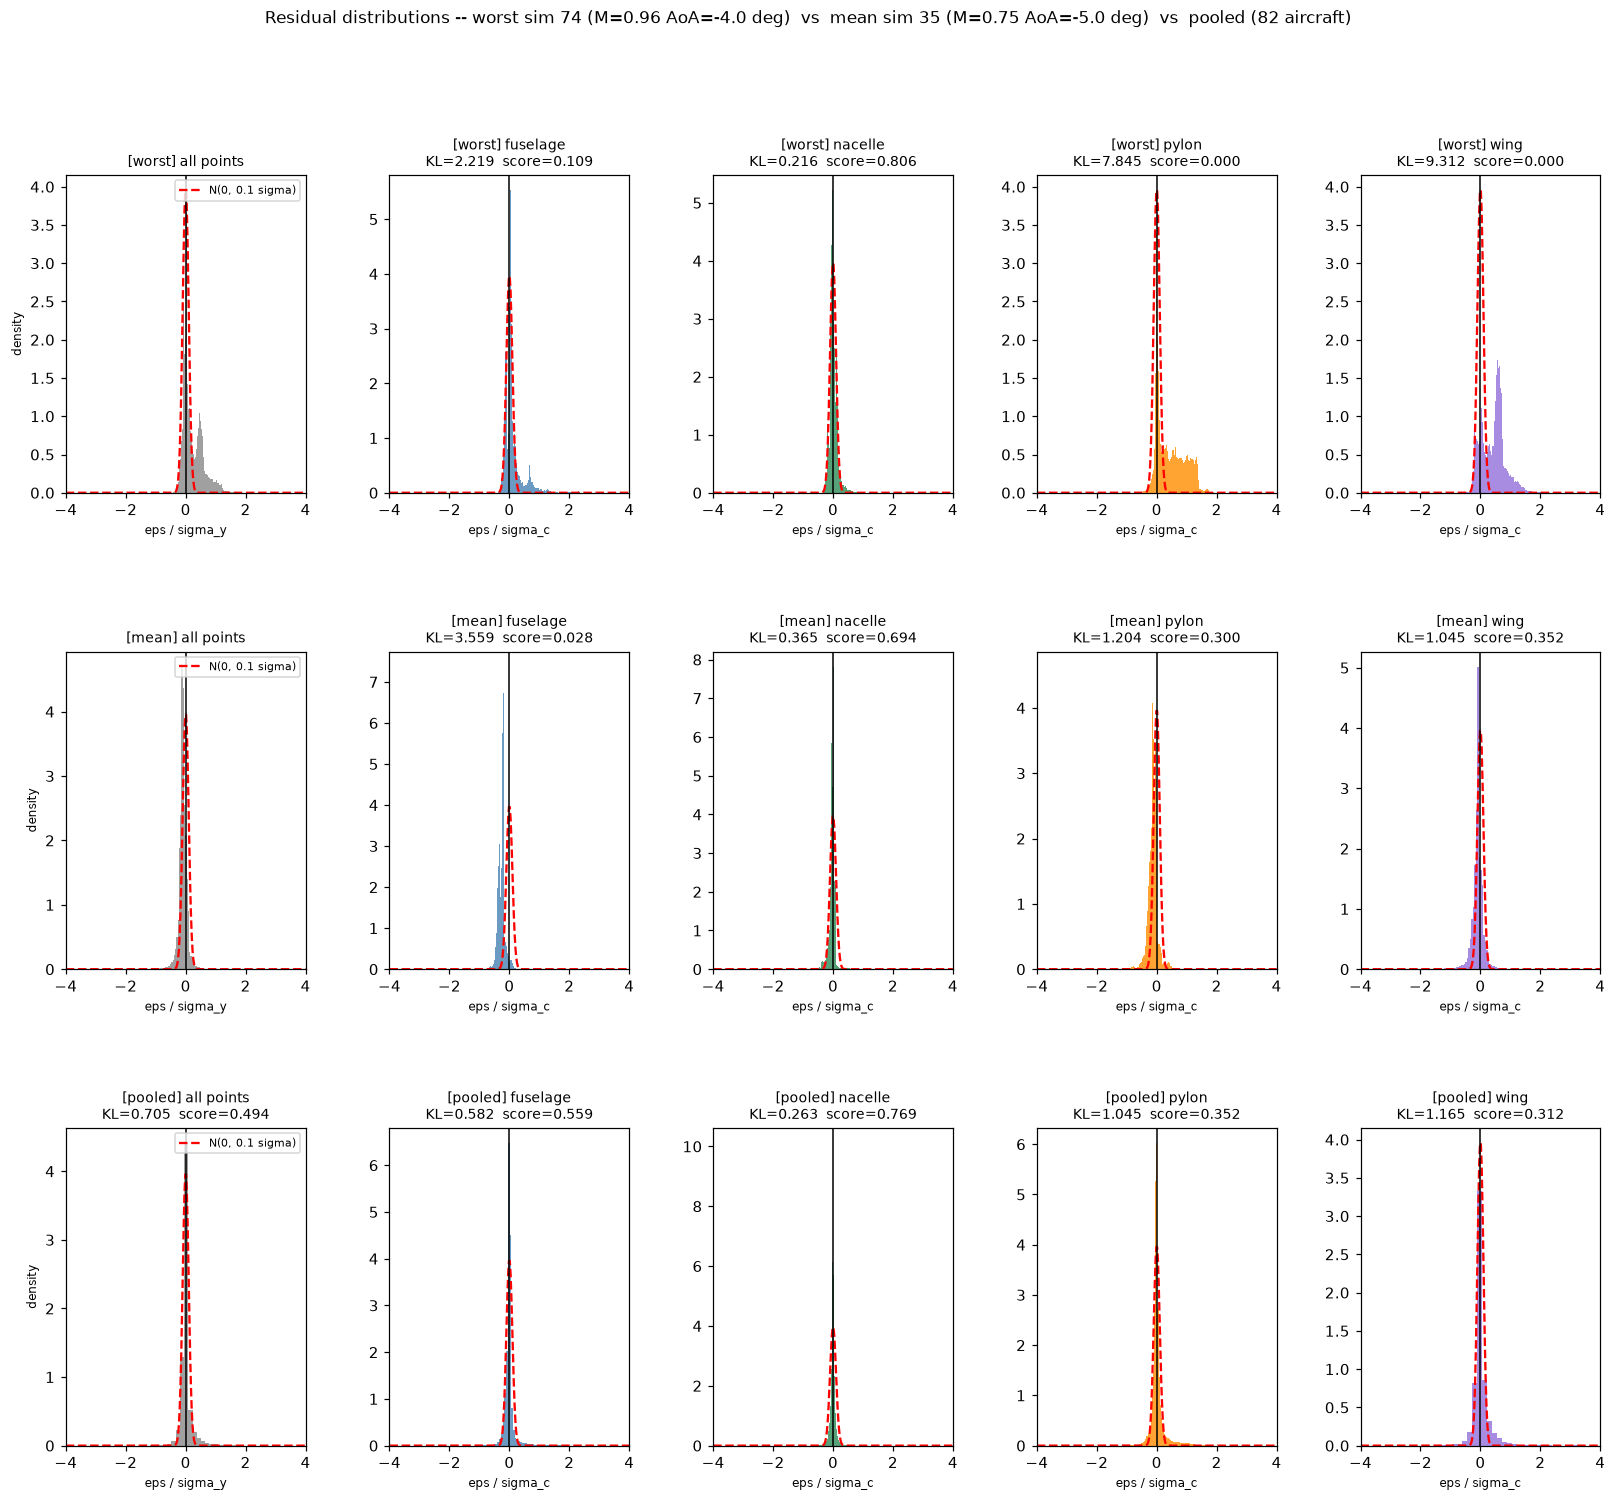

In [7]:
print(f'\n{"="*60}')
print(f'  Residual KL-Normal metrics -- random split (80/20, seed=42)')
print(f'{"="*60}')

global_results = []
comp_results   = {v: [] for v in component_map.values()}

for i in range(n_test):
    if weights_sim[i] < 1.0:
        global_results.append(None)
        for c in comp_results:
            comp_results[c].append(None)
        continue
    gs_kl = residual_kl_normal(Y[i], Yh[i])
    global_results.append(gs_kl)
    for cid, cname in component_map.items():
        mask = component_labels == cid
        comp_results[cname].append(residual_kl_normal(Y[i][mask], Yh[i][mask]))

valid_idx   = [i for i, g in enumerate(global_results) if g is not None]
kl_vals     = np.array([global_results[i]['kl']     for i in valid_idx])
score_vals  = np.array([global_results[i]['score']  for i in valid_idx])
bias_vals   = np.array([global_results[i]['bias']   for i in valid_idx])
spread_vals = np.array([global_results[i]['spread'] for i in valid_idx])

print(f'\n  Global (all points):')
print(f'    KL    mean={kl_vals.mean():.4f}  max={kl_vals.max():.4f}  min={kl_vals.min():.4f}')
print(f'    score mean={score_vals.mean():.4f}  min={score_vals.min():.4f}  (higher=better)')
print(f'    bias  mean={bias_vals.mean():.4f}  std={bias_vals.std():.4f}')
print(f'    spread mean={spread_vals.mean():.4f}  max={spread_vals.max():.4f}')

eps_pool_y  = np.concatenate([Y[i]  for i in valid_idx])
eps_pool_yh = np.concatenate([Yh[i] for i in valid_idx])
pooled_kl   = residual_kl_normal(eps_pool_y, eps_pool_yh)

print(f'\n  Global (pooled, all aircraft concatenated):')
print(f'    KL    ={pooled_kl["kl"]:.4f}')
print(f'    score ={pooled_kl["score"]:.4f}  (higher=better)')
print(f'    bias  ={pooled_kl["bias"]:.4f}')
print(f'    spread={pooled_kl["spread"]:.4f}')

iworst = valid_idx[int(np.argmin(score_vals))]
ibest  = valid_idx[int(np.argmax(score_vals))]
print(f'\n  Worst sim : {iworst}  Mach={conds[test_sims[iworst],0]:.2f}  '
      f'AoA={conds[test_sims[iworst],1]:.1f} deg  '
      f'KL={kl_vals.min():.4f}  score={score_vals.min():.4f}')
print(f'  Best  sim : {ibest}   Mach={conds[test_sims[ibest],0]:.2f}  '
      f'AoA={conds[test_sims[ibest],1]:.1f} deg  '
      f'KL={kl_vals.max():.4f}  score={score_vals.max():.4f}')

print(f'\n  Per component:')
print(f'  {"component":<12}  {"mean KL":>9}  {"max KL":>9}  {"mean score":>10}  '
      f'{"mean bias":>10}  {"mean spread":>11}')
print(f'  {"─"*12}  {"─"*9}  {"─"*9}  {"─"*10}  {"─"*10}  {"─"*11}')
for cname in component_map.values():
    vals  = [v for v in comp_results[cname] if v is not None]
    kl_c  = np.array([v['kl']     for v in vals])
    sc_c  = np.array([v['score']  for v in vals])
    bi_c  = np.array([v['bias']   for v in vals])
    sp_c  = np.array([v['spread'] for v in vals])
    print(f'  {cname:<12}  {kl_c.mean():>9.4f}  {kl_c.max():>9.4f}  '
          f'{sc_c.mean():>10.4f}  {bi_c.mean():>10.4f}  {sp_c.mean():>11.4f}')

print(f'\n  Worst sim detail by component (sim {iworst}):')
print(f'  {"component":<12}  {"KL":>9}  {"score":>9}  {"bias":>9}  {"spread":>9}')
print(f'  {"─"*12}  {"─"*9}  {"─"*9}  {"─"*9}  {"─"*9}')
for cname in component_map.values():
    v = comp_results[cname][iworst]
    if v is not None:
        print(f'  {cname:<12}  {v["kl"]:>9.4f}  {v["score"]:>9.4f}  '
              f'{v["bias"]:>9.4f}  {v["spread"]:>9.4f}')
print(f'{"="*60}')

worst_i = 74
mean_i  = valid_idx[int(np.argmin(np.abs(score_vals - score_vals.mean())))]

fig = plt.figure(figsize=(18, 15), dpi=110)
fig.suptitle(
    f'Residual distributions -- worst sim {worst_i} '
    f'(M={conds[test_sims[worst_i],0]:.2f} AoA={conds[test_sims[worst_i],1]:.1f} deg)'
    f'  vs  mean sim {mean_i} '
    f'(M={conds[test_sims[mean_i],0]:.2f} AoA={conds[test_sims[mean_i],1]:.1f} deg)'
    f'  vs  pooled ({len(valid_idx)} aircraft)',
    fontsize=11
)
gs_fig = gridspec.GridSpec(3, 5, figure=fig, hspace=0.5, wspace=0.35)

cnames = list(component_map.values())
colors = {'fuselage': 'steelblue', 'nacelle': 'seagreen',
          'pylon': 'darkorange', 'wing': 'mediumpurple'}
sims   = {'worst': worst_i, 'mean': mean_i}
x_ref     = np.linspace(-4, 4, 300)
sigma_ref = 0.1

for row, (row_label, sim_i) in enumerate(sims.items()):
    sigma_y_global = Y[sim_i].std()

    ax_all  = fig.add_subplot(gs_fig[row, 0])
    eps_all = (Yh[sim_i] - Y[sim_i]) / sigma_y_global
    ax_all.hist(eps_all, bins=120, color='gray', density=True, alpha=0.75)
    ax_all.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5,
                label=f'N(0, {sigma_ref} sigma)')
    ax_all.axvline(0, color='black', lw=1)
    ax_all.set_xlim(-4, 4)
    ax_all.set_xlabel('eps / sigma_y', fontsize=8)
    ax_all.set_ylabel('density', fontsize=8)
    ax_all.set_title(f'[{row_label}] all points', fontsize=9)
    ax_all.legend(fontsize=7)

    for col, cname in enumerate(cnames, start=1):
        cid    = [k for k, v in component_map.items() if v == cname][0]
        mask   = component_labels == cid
        sigma_c = Y[sim_i][mask].std() + 1e-12
        eps_c   = (Yh[sim_i][mask] - Y[sim_i][mask]) / sigma_c
        res     = comp_results[cname][sim_i]
        kl_v    = res['kl']    if res else float('nan')
        sc_v    = res['score'] if res else float('nan')

        ax = fig.add_subplot(gs_fig[row, col])
        ax.hist(eps_c, bins=100, color=colors[cname], density=True, alpha=0.8)
        ax.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlim(-4, 4)
        ax.set_xlabel('eps / sigma_c', fontsize=8)
        ax.set_title(f'[{row_label}] {cname}\nKL={kl_v:.3f}  score={sc_v:.3f}', fontsize=9)

comp_labels_pool = np.tile(component_labels, len(valid_idx))
sigma_y_pool     = eps_pool_y.std() + 1e-12
eps_all_pool     = (eps_pool_yh - eps_pool_y) / sigma_y_pool

ax_all = fig.add_subplot(gs_fig[2, 0])
ax_all.hist(eps_all_pool, bins=120, color='gray', density=True, alpha=0.75)
ax_all.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5,
            label=f'N(0, {sigma_ref} sigma)')
ax_all.axvline(0, color='black', lw=1)
ax_all.set_xlim(-4, 4)
ax_all.set_xlabel('eps / sigma_y', fontsize=8)
ax_all.set_ylabel('density', fontsize=8)
ax_all.set_title(f'[pooled] all points\nKL={pooled_kl["kl"]:.3f}  score={pooled_kl["score"]:.3f}', fontsize=9)
ax_all.legend(fontsize=7)

for col, cname in enumerate(cnames, start=1):
    cid     = [k for k, v in component_map.items() if v == cname][0]
    mask    = comp_labels_pool == cid
    sigma_c = eps_pool_y[mask].std() + 1e-12
    eps_c   = (eps_pool_yh[mask] - eps_pool_y[mask]) / sigma_c
    res_c   = residual_kl_normal(eps_pool_y[mask], eps_pool_yh[mask])

    ax = fig.add_subplot(gs_fig[2, col])
    ax.hist(eps_c, bins=100, color=colors[cname], density=True, alpha=0.8)
    ax.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlim(-4, 4)
    ax.set_xlabel('eps / sigma_c', fontsize=8)
    ax.set_title(f'[pooled] {cname}\nKL={res_c["kl"]:.3f}  score={res_c["score"]:.3f}', fontsize=9)

plt.savefig('residual_distributions_worst_vs_mean.png', dpi=150, bbox_inches='tight')
print('Saved: residual_distributions_worst_vs_mean.png')
plt.show()

## 9. Global MLP -- Architecture and Training

Implements the Global MLP described in the paper (Section 5.1).
The model maps 3 aerodynamic conditions (Mach, AoA, Pi) to the full
parietal density field of nwallp = 260774 points in a single forward pass.

Architecture (literal from paper):

    input(3) -> Linear(3,75) -> ReLU
             -> Linear(75,120) -> ReLU
             -> Linear(120,1226) -> ReLU
             -> Linear(1226,16490) -> ReLU
             -> Linear(16490,nwallp)

The paper describes 'five hidden layers of size (75, 120, 1226, 16490)' --
four listed sizes plus the output layer of size nwallp. Training is
field-by-field: each simulation is one sample (batch_size=1 during training).
The output weight matrix alone is ~17 GB (float32); a large-memory CPU node
is required, as stated in the paper ('sustainable with current CPU nodes').

Target values are standardized per-dataset (zero mean, unit variance) before
training and inverse-transformed for evaluation.


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Architecture parameters (from paper Section 5.1) ─────────────────────
HIDDEN_SIZES = [75, 120, 1226, 16490]  # four hidden layers
INPUT_SIZE   = 3                        # (Mach, AoA, Pi)
OUTPUT_SIZE  = nwallp                   # full field: 260774

# ── Training hyper-parameters ────────────────────────────────────────────
LR          = 1e-3
N_EPOCHS    = 200
PATIENCE    = 20      # early stopping patience (epochs without val improvement)
BATCH_SIZE  = 8       # number of simulations per gradient step
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class GlobalMLP(nn.Module):
    """
    Maps a vector of 3 aerodynamic conditions to the full parietal field
    (nwallp values). Architecture from ONERA CRM paper Section 5.1.
    """
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Data loading (reuses nwallp and COL_* from section 2) ────────────────
print('Loading full dataset...')
X_all = np.load(DATA_DIR + 'X9_ALL_POINT_fl32.npy')            # (n_sims*nwallp, 9)
y_all = np.load(DATA_DIR + 'RHO_ALL_POINT_fl32.npy')[:, 0]    # (n_sims*nwallp,)

n_sims = X_all.shape[0] // nwallp
conds  = X_all[::nwallp, COL_MINF:COL_PI+1].astype(np.float32)  # (n_sims, 3)
fields = y_all.reshape(n_sims, nwallp).astype(np.float32)        # (n_sims, nwallp)

# ── Train / validation split (80/20, same seed as KNN section) ───────────
sim_idx               = np.arange(n_sims)
train_sims, val_sims  = train_test_split(sim_idx, test_size=0.2, random_state=SEED)

conds_train  = conds [train_sims]    # (n_train, 3)
fields_train = fields[train_sims]    # (n_train, nwallp)
conds_val    = conds [val_sims]      # (n_val,   3)
fields_val   = fields[val_sims]      # (n_val,   nwallp)

# ── Normalise inputs (conditions) ────────────────────────────────────────
cond_scaler   = StandardScaler().fit(conds_train)
conds_train_n = cond_scaler.transform(conds_train).astype(np.float32)
conds_val_n   = cond_scaler.transform(conds_val  ).astype(np.float32)

# ── Normalise outputs (field values, global stats over train set) ─────────
y_mean = float(fields_train.mean())
y_std  = float(fields_train.std()) + 1e-12
fields_train_n = (fields_train - y_mean) / y_std
fields_val_n   = (fields_val   - y_mean) / y_std

# ── PyTorch tensors and DataLoaders ──────────────────────────────────────
train_ds = TensorDataset(
    torch.from_numpy(conds_train_n),
    torch.from_numpy(fields_train_n)
)
val_ds = TensorDataset(
    torch.from_numpy(conds_val_n),
    torch.from_numpy(fields_val_n)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

# ── Model, optimiser, scheduler ──────────────────────────────────────────
model     = GlobalMLP(INPUT_SIZE, HIDDEN_SIZES, OUTPUT_SIZE).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)
criterion = nn.MSELoss()

n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {n_params:,}')
print(f'Train sims       : {len(train_sims)}   Val sims: {len(val_sims)}')

# ── Training loop with early stopping ────────────────────────────────────
best_val_loss  = float('inf')
best_state     = None
patience_count = 0
history        = {'train': [], 'val': []}

print(f'\nTraining for up to {N_EPOCHS} epochs (early stopping patience={PATIENCE})...')
for epoch in range(1, N_EPOCHS + 1):
    # -- train --
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)

    # -- validate --
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(xb), yb).item() * len(xb)
    val_loss /= len(val_ds)

    history['train'].append(train_loss)
    history['val'].append(val_loss)
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'  epoch {epoch:4d}  train_MSE={train_loss:.6f}  val_MSE={val_loss:.6f}')

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'  Early stopping at epoch {epoch} (best val MSE={best_val_loss:.6f})')
            break

model.load_state_dict(best_state)
print(f'\nBest val MSE (normalised): {best_val_loss:.6f}')

# ── Save checkpoint ───────────────────────────────────────────────────────
torch.save({
    'model_state': best_state,
    'cond_scaler_mean': cond_scaler.mean_,
    'cond_scaler_scale': cond_scaler.scale_,
    'y_mean': y_mean,
    'y_std' : y_std,
    'hidden_sizes': HIDDEN_SIZES,
    'input_size'  : INPUT_SIZE,
    'output_size' : OUTPUT_SIZE,
    'train_sims'  : train_sims,
    'val_sims'    : val_sims,
}, 'global_mlp_checkpoint.pt')
print('Checkpoint saved: global_mlp_checkpoint.pt')

# ── Loss curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(history['train'], label='train MSE')
ax.semilogy(history['val'],   label='val MSE')
ax.set_xlabel('epoch')
ax.set_ylabel('MSE (normalised)')
ax.set_title('Global MLP -- training / validation loss curve')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('global_mlp_loss_curve.png', dpi=150)
plt.show()


Loading full dataset...
Model parameters : 4,320,815,030
Train sims       : 374   Val sims: 94

Training for up to 200 epochs (early stopping patience=20)...


OutOfMemoryError: CUDA out of memory. Tried to allocate 16.02 GiB. GPU 0 has a total capacity of 31.73 GiB of which 15.20 GiB is free. Including non-PyTorch memory, this process has 16.53 GiB memory in use. Of the allocated memory 16.14 GiB is allocated by PyTorch, and 21.16 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## 10. Global MLP -- Evaluation (wrMAE, R2, KL Score)

Generates predictions on the validation set, inverse-transforms them to
physical density values, then computes:

- **per-simulation R2** and **wrMAE** (same metric as Codabench)
- **residual_kl_normal score** per simulation and per component
  (reuses the function defined in Section 8)
- **Worst-condition 3-D scatter** for visual inspection
- **Residual distribution plots** (worst vs median simulation)

All metric functions from Sections 7 and 8 are reused directly.


In [ ]:
# ── Inference on validation set ──────────────────────────────────────────
model.eval()
preds_list = []
with torch.no_grad():
    for xb, _ in val_loader:
        preds_list.append(model(xb.to(DEVICE)).cpu().numpy())

preds_norm = np.concatenate(preds_list, axis=0)         # (n_val, nwallp) -- normalised
preds_phys = preds_norm * y_std + y_mean                 # back to physical density

y_val_phys = fields_val                                  # (n_val, nwallp)
n_val      = len(val_sims)

# weights: down-weight |AoA| >= 10 deg
aoa_val      = conds_val[:, 1]  # raw (not normalised)
weights_val  = np.where(np.abs(aoa_val) < 10.0, 1.0, 0.5)
machs_val    = conds_val[:, 0]

# ── Per-simulation R2 and relMAE ─────────────────────────────────────────
r2_mlp, relMAE_mlp, weighted_idx_mlp = [], [], []
relMAEs_w_mlp = []
comp_relMAEs_mlp = {v: [] for v in component_map.values()}

for i in range(n_val):
    yc    = y_val_phys[i]
    yhatc = preds_phys[i]
    err   = np.abs(yc - yhatc)

    ss_res = np.sum((yc - yhatc)**2)
    ss_tot = np.sum((yc - yc.mean())**2)
    r2_mlp.append(1.0 - ss_res / (ss_tot + 1e-12))

    if weights_val[i] >= 1.0:
        relMAEs_w_mlp.append(float(np.mean(err) / (np.mean(np.abs(yc)) + 1e-12)))
        weighted_idx_mlp.append(i)
        for cid, cname in component_map.items():
            mask = component_labels == cid
            comp_relMAEs_mlp[cname].append(
                float(np.mean(err[mask]) / (np.mean(np.abs(yc[mask])) + 1e-12))
            )

r2_mlp    = np.array(r2_mlp)
wrMAE_mlp = float(np.max(relMAEs_w_mlp))
iworst_loc_mlp = int(np.argmax(relMAEs_w_mlp))
iworst_mlp     = weighted_idx_mlp[iworst_loc_mlp]

print(f'{"="*60}')
print(f'  Global MLP -- Validation Metrics')
print(f'{"="*60}')
print(f'  Val sims : {n_val}')
print(f'  Per-sim R2  mean={r2_mlp.mean():.4f}  min={r2_mlp.min():.4f}  '
      f'p05={np.percentile(r2_mlp,5):.4f}')
print(f'  wrMAE       {wrMAE_mlp:.4f}  '
      f'(sim {val_sims[iworst_mlp]}  '
      f'Mach={machs_val[iworst_mlp]:.2f}  '
      f'AoA={aoa_val[iworst_mlp]:.1f} deg)')
print(f'\n  wrMAE by component:')
for cname, vals in comp_relMAEs_mlp.items():
    if vals:
        print(f'    {cname:<12}  wrMAE={max(vals):.4f}  mean={np.mean(vals):.4f}')
print(f'{"="*60}')

# ── Residual KL score (reuses residual_kl_normal from Section 8) ─────────
print(f'\n{"="*60}')
print(f'  Global MLP -- Residual KL-Normal Score')
print(f'{"="*60}')

kl_results_mlp   = []
comp_kl_mlp      = {v: [] for v in component_map.values()}

for i in range(n_val):
    if weights_val[i] < 1.0:
        kl_results_mlp.append(None)
        for c in comp_kl_mlp:
            comp_kl_mlp[c].append(None)
        continue
    res = residual_kl_normal(y_val_phys[i], preds_phys[i])
    kl_results_mlp.append(res)
    for cid, cname in component_map.items():
        mask = component_labels == cid
        comp_kl_mlp[cname].append(
            residual_kl_normal(y_val_phys[i][mask], preds_phys[i][mask])
        )

valid_kl_idx = [i for i, g in enumerate(kl_results_mlp) if g is not None]
kl_arr    = np.array([kl_results_mlp[i]['kl']    for i in valid_kl_idx])
score_arr = np.array([kl_results_mlp[i]['score'] for i in valid_kl_idx])
bias_arr  = np.array([kl_results_mlp[i]['bias']  for i in valid_kl_idx])
sprd_arr  = np.array([kl_results_mlp[i]['spread']for i in valid_kl_idx])

print(f'\n  Global (all points):')
print(f'    KL    mean={kl_arr.mean():.4f}  max={kl_arr.max():.4f}  min={kl_arr.min():.4f}')
print(f'    score mean={score_arr.mean():.4f}  min={score_arr.min():.4f}  (higher=better)')
print(f'    bias  mean={bias_arr.mean():.4f}  std={bias_arr.std():.4f}')
print(f'    spread mean={sprd_arr.mean():.4f}  max={sprd_arr.max():.4f}')

iworst_kl = valid_kl_idx[int(np.argmin(score_arr))]
ibest_kl  = valid_kl_idx[int(np.argmax(score_arr))]
print(f'\n  Worst sim : {iworst_kl}  '
      f'Mach={machs_val[iworst_kl]:.2f}  AoA={aoa_val[iworst_kl]:.1f} deg  '
      f'score={score_arr.min():.4f}')
print(f'  Best  sim : {ibest_kl}  '
      f'Mach={machs_val[ibest_kl]:.2f}  AoA={aoa_val[ibest_kl]:.1f} deg  '
      f'score={score_arr.max():.4f}')

print(f'\n  Per component:')
print(f'  {"component":<12}  {"mean KL":>9}  {"max KL":>9}  '
      f'{"mean score":>10}  {"mean bias":>10}  {"mean spread":>11}')
print(f'  {"─"*12}  {"─"*9}  {"─"*9}  {"─"*10}  {"─"*10}  {"─"*11}')
for cname in component_map.values():
    vals = [v for v in comp_kl_mlp[cname] if v is not None]
    if not vals:
        continue
    kl_c = np.array([v['kl']     for v in vals])
    sc_c = np.array([v['score']  for v in vals])
    bi_c = np.array([v['bias']   for v in vals])
    sp_c = np.array([v['spread'] for v in vals])
    print(f'  {cname:<12}  {kl_c.mean():>9.4f}  {kl_c.max():>9.4f}  '
          f'{sc_c.mean():>10.4f}  {bi_c.mean():>10.4f}  {sp_c.mean():>11.4f}')
print(f'{"="*60}')

# ── Worst-condition 3-D scatter ───────────────────────────────────────────
X_coords = X_all[:nwallp, :3]  # shared geometry

def plot_condition_mlp(i_sim, y_true_2d, y_pred_2d, conds_arr, val_sims_arr, label):
    """3-D scatter: ground truth / prediction / absolute error for one simulation."""
    yc    = y_true_2d[i_sim]
    yhatc = y_pred_2d[i_sim]
    err   = np.abs(yc - yhatc)
    Minf  = conds_arr[i_sim, 0]
    AoA   = conds_arr[i_sim, 1]
    Pi    = conds_arr[i_sim, 2]

    def _scale(field):
        f03, f50, f97 = np.percentile(field, [3., 50., 97.])
        sm = (f50 - f03) / 0.47
        sp = (f97 - f50) / 0.47
        return max(0., f50 - 0.6*sm), f50 + 0.6*sp

    fields_plt = [yc, yhatc, err]
    titles_plt = ['Ground truth rho', 'MLP prediction rho', 'Absolute error']
    cmaps_plt  = ['jet', 'jet', 'Reds']

    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[{label}] sim {val_sims_arr[i_sim]}  --  '
        f'Minf={Minf:.2f}  AoA={AoA:.1f} deg  Pi={Pi:.2e} Pa',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(fields_plt, titles_plt, cmaps_plt)):
        gs_p = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax   = fig.add_subplot(gs_p[0, col], projection='3d')
        fmin, fmax = _scale(field)
        sca = ax.scatter3D(
            X_coords[:, 0], X_coords[:, 1], X_coords[:, 2],
            c=field, vmin=fmin, vmax=fmax, cmap=cmap, s=0.3, alpha=0.8
        )
        ax.view_init(elev=20, azim=120)
        ax.set_xlim(X_coords[:,0].min()-5., X_coords[:,0].max()+5.)
        ax.set_ylim(X_coords[:,1].min()-5., X_coords[:,1].max()+5.)
        ax.set_zlim(X_coords[:,2].min(),    X_coords[:,2].max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs_p[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'mlp_{label.lower().replace(" ","_")}_sim{val_sims_arr[i_sim]}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


plot_condition_mlp(iworst_mlp, y_val_phys, preds_phys, conds_val, val_sims, 'worst wrMAE')
plot_condition_mlp(iworst_kl,  y_val_phys, preds_phys, conds_val, val_sims, 'worst KL')

# ── Residual distribution: worst vs median simulation ────────────────────
mean_kl_i = valid_kl_idx[int(np.argmin(np.abs(score_arr - score_arr.mean())))]
cnames_plot = list(component_map.values())
colors_plot = {'fuselage': 'steelblue', 'nacelle': 'seagreen',
               'pylon': 'darkorange', 'wing': 'mediumpurple'}
sims_plot = {'worst': iworst_kl, 'median': mean_kl_i}

fig = plt.figure(figsize=(18, 10), dpi=110)
fig.suptitle(
    f'Global MLP -- Residual distributions\n'
    f'worst sim {iworst_kl} '
    f'(M={machs_val[iworst_kl]:.2f} AoA={aoa_val[iworst_kl]:.1f} deg)'
    f'  vs  median sim {mean_kl_i} '
    f'(M={machs_val[mean_kl_i]:.2f} AoA={aoa_val[mean_kl_i]:.1f} deg)',
    fontsize=11
)
gs_rd = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)
x_ref     = np.linspace(-4, 4, 300)
sigma_ref = 0.1

for row, (row_label, sim_i) in enumerate(sims_plot.items()):
    sigma_g = y_val_phys[sim_i].std() + 1e-12
    eps_all = (preds_phys[sim_i] - y_val_phys[sim_i]) / sigma_g

    ax_all = fig.add_subplot(gs_rd[row, 0])
    ax_all.hist(eps_all, bins=120, color='gray', density=True, alpha=0.75)
    ax_all.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5,
                label=f'N(0,{sigma_ref}sigma)')
    ax_all.axvline(0, color='black', lw=1)
    ax_all.set_xlim(-4, 4)
    ax_all.set_xlabel('eps / sigma_y', fontsize=8)
    ax_all.set_ylabel('density', fontsize=8)
    ax_all.set_title(f'[{row_label}] all points', fontsize=9)
    ax_all.legend(fontsize=7)

    for col, cname in enumerate(cnames_plot, start=1):
        cid    = [k for k, v in component_map.items() if v == cname][0]
        mask   = component_labels == cid
        sigma_c = y_val_phys[sim_i][mask].std() + 1e-12
        eps_c   = (preds_phys[sim_i][mask] - y_val_phys[sim_i][mask]) / sigma_c
        res     = comp_kl_mlp[cname][sim_i]
        kl_v    = res['kl']    if res else float('nan')
        sc_v    = res['score'] if res else float('nan')

        ax = fig.add_subplot(gs_rd[row, col])
        ax.hist(eps_c, bins=100, color=colors_plot[cname], density=True, alpha=0.8)
        ax.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlim(-4, 4)
        ax.set_xlabel('eps / sigma_c', fontsize=8)
        ax.set_title(
            f'[{row_label}] {cname}\nKL={kl_v:.3f}  score={sc_v:.3f}', fontsize=9
        )

plt.savefig('mlp_residual_distributions.png', dpi=150, bbox_inches='tight')
print('Saved: mlp_residual_distributions.png')
plt.show()

# ── Summary comparison: MLP vs KNN (from Section 7) ──────────────────────
print(f'\n{"="*60}')
print(f'  Model comparison -- Global MLP vs KNN (same val split)')
print(f'{"="*60}')
print(f'  Metric          Global MLP     KNN (Section 7)')
print(f'  {"─"*50}')
print(f'  mean R2         {r2_mlp.mean():.4f}         {'':>6} (run Section 7 first)')
print(f'  min R2          {r2_mlp.min():.4f}')
print(f'  wrMAE           {wrMAE_mlp:.4f}')
print(f'  mean KL score   {score_arr.mean():.4f}         (higher=better)')
print(f'  min KL score    {score_arr.min():.4f}')
print(f'{"="*60}')


NameError: name 'model' is not defined

## 11. Decision Tree Regressor

Pointwise regression tree following Breiman et al. Each wall point is
treated as an independent sample: input = 9 features (x, y, z, Mach,
AoA, Pi, ...), output = scalar density. The tree partitions the feature
space by minimizing squared error at each split.

Key settings from the paper:
- No max_depth limit (paper reports depth 108 on their data)
- min_samples_leaf = 1 (best accuracy; paper notes going to 30 costs < 0.01 R2)
- Trained on all available train+val data for the final model (no held-out set)
  but we first do a train/val run to compare metrics with KNN and MLP.

Evaluated with the same wrMAE, per-sim R2, and residual_kl_normal score.

Building pointwise train/val arrays (9-feature, pointwise)...
Train points : 97,529,476
Val   points : 24,512,756

Cache found at 'dt_predictions.json' — skipping training and prediction.
Loaded y_pred_dt : (24512756,)

  Decision Tree -- Validation Metrics
  Per-sim R2  mean=0.9741  min=0.6861  p05=0.9124
  wrMAE       0.0432  (sim 289  Mach=0.93  AoA=-6.0 deg)

  wrMAE by component:
    fuselage      wrMAE=0.0211  mean=0.0047
    nacelle       wrMAE=0.0100  mean=0.0047
    pylon         wrMAE=0.0795  mean=0.0091
    wing          wrMAE=0.0746  mean=0.0153

  Decision Tree -- Residual KL-Normal Score

  Global (all points):
    KL    mean=0.6545  max=1.9179  min=0.2706
    score mean=0.5338  min=0.1469  (higher=better)
    bias  mean=-0.0047  std=0.0161
    spread mean=0.0960  max=0.3017

  Worst sim : 53  Mach=0.93  AoA=-6.0 deg  score=0.1469
  Best  sim : 54  Mach=0.86  AoA=-3.0 deg  score=0.7629

  Per component:
  component       mean KL     max KL  mean score   mean bias  mean sp

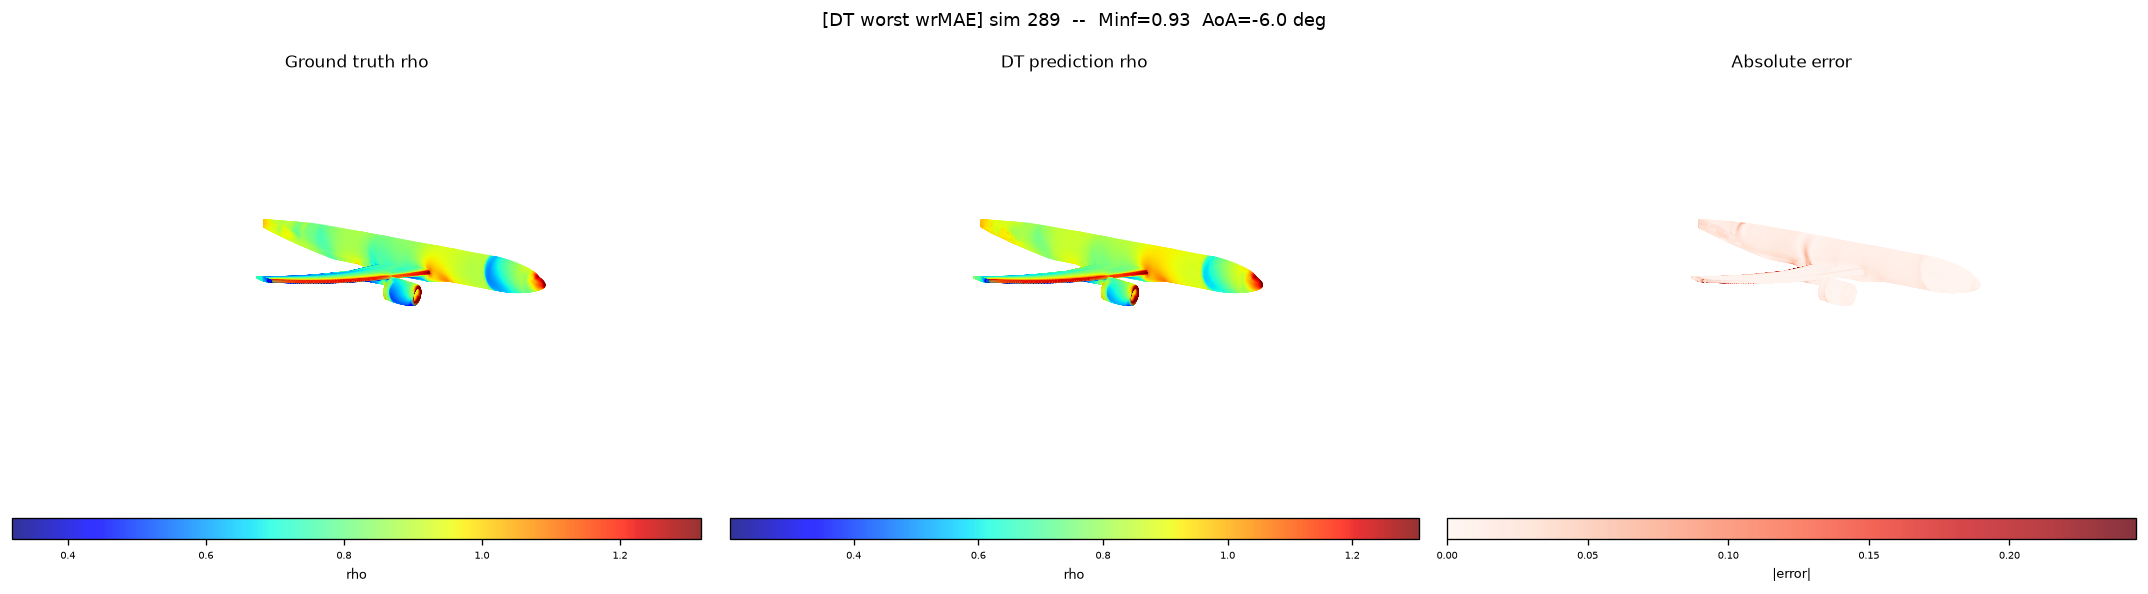

Saved: dt_worst_KL_sim289.png


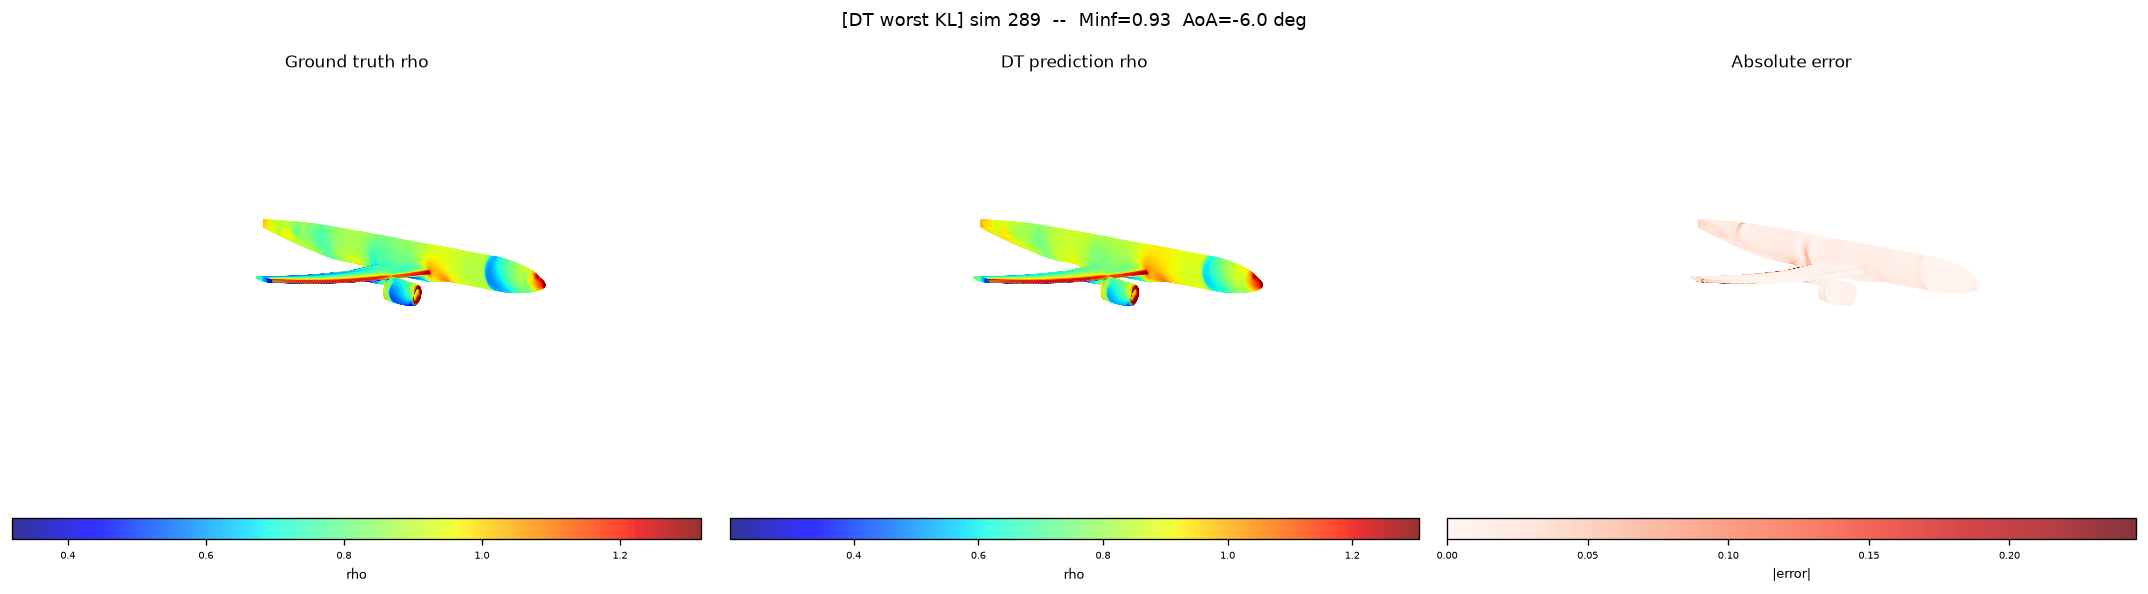

Saved: dt_residual_distributions.png


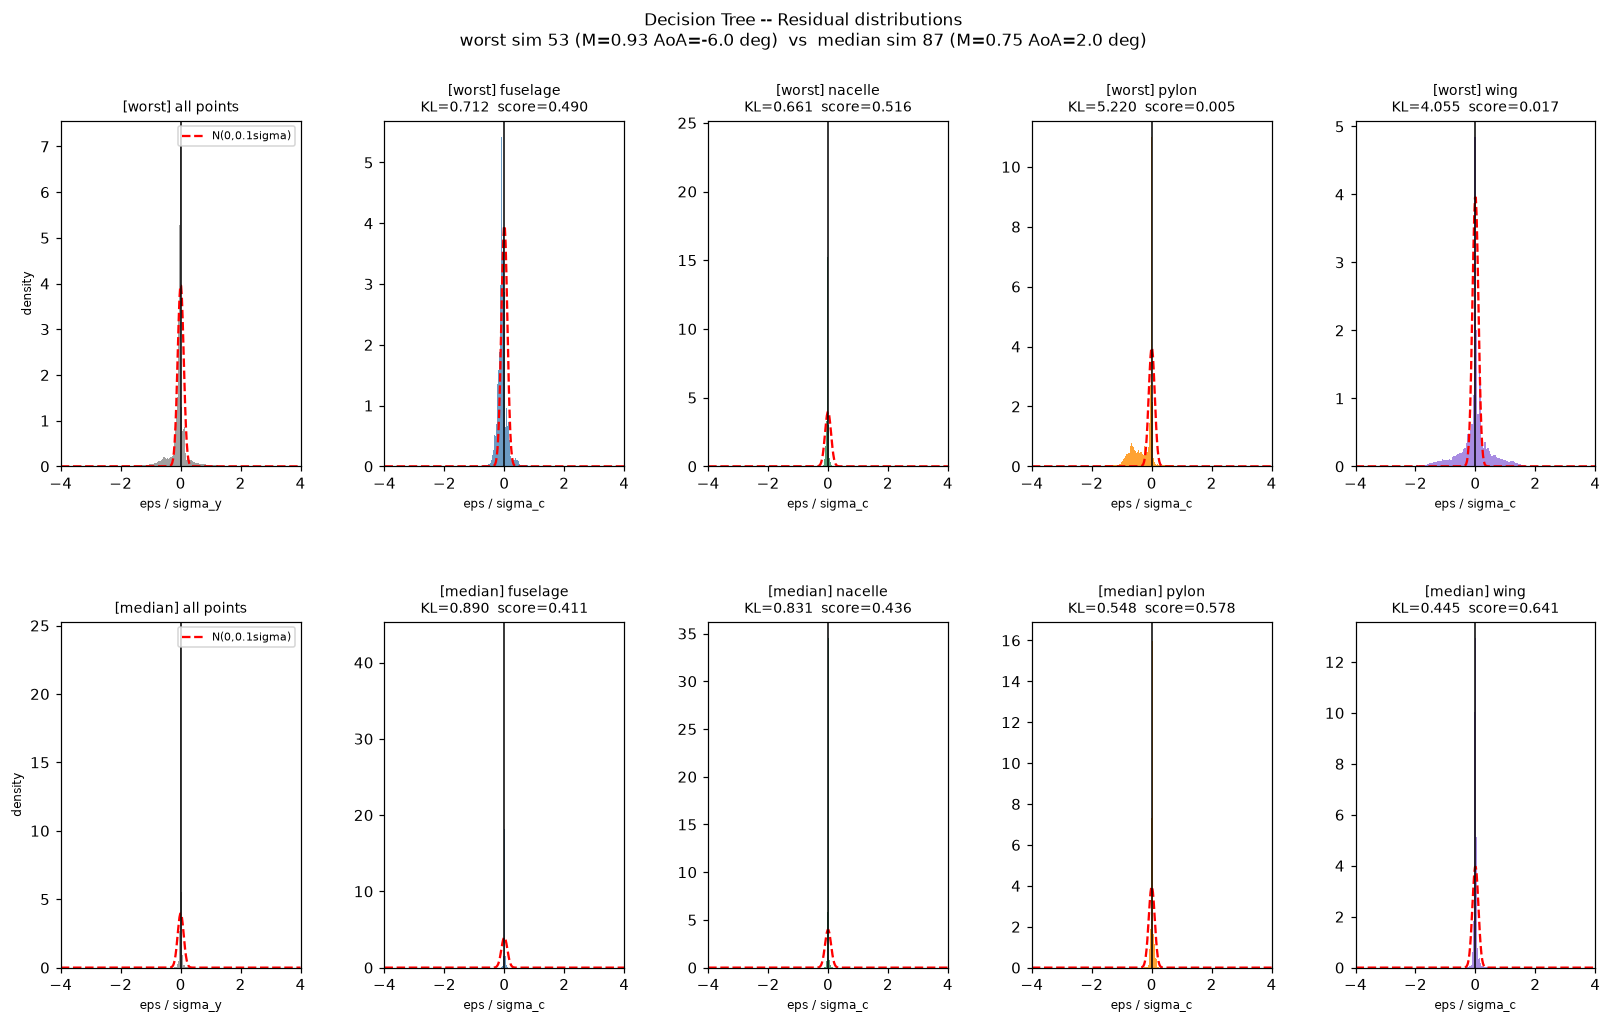


  Model comparison -- val split (80/20, seed=42)
  Model            mean R2    min R2     wrMAE   mean KL score
  ──────────────  ────────  ────────  ────────  ──────────────
  Decision Tree     0.9741    0.6861    0.0432          0.5338


In [10]:
import json, os
from sklearn.tree import DecisionTreeRegressor

CACHE_PATH = 'dt_predictions.json'

# ── Data (reuses X_all, y_all, train_sims, val_sims, conds, fields from Section 7) ──
print('Building pointwise train/val arrays (9-feature, pointwise)...')
pt_train_idx = np.concatenate([
    np.arange(i*nwallp, (i+1)*nwallp) for i in train_sims
])
pt_val_idx = np.concatenate([
    np.arange(i*nwallp, (i+1)*nwallp) for i in val_sims
])

X_pt_train = X_all[pt_train_idx]
y_pt_train = y_all[pt_train_idx]
X_pt_val   = X_all[pt_val_idx]
y_pt_val   = y_all[pt_val_idx]

print(f'Train points : {X_pt_train.shape[0]:,}')
print(f'Val   points : {X_pt_val.shape[0]:,}')

# ── Load from cache or train ──────────────────────────────────────────────────
if os.path.exists(CACHE_PATH):
    print(f'\nCache found at {CACHE_PATH!r} — skipping training and prediction.')
    with open(CACHE_PATH, 'r') as f:
        cache = json.load(f)
    y_pred_dt = np.array(cache['y_pred_dt'])
    y_pt_val  = np.array(cache['y_pt_val'])
    print(f'Loaded y_pred_dt : {y_pred_dt.shape}')
    dt = None  # no model in memory when loading from cache
else:
    print('\nNo cache found. Fitting Decision Tree (no depth limit, min_samples_leaf=1)...')
    dt = DecisionTreeRegressor(
        criterion='squared_error',
        max_depth=None,
        min_samples_leaf=1,
        random_state=SEED
    )
    dt.fit(X_pt_train, y_pt_train)
    print(f'Tree depth     : {dt.get_depth()}')
    print(f'Tree n_leaves  : {dt.get_n_leaves():,}')

    print('\nPredicting on val set...')
    y_pred_dt = dt.predict(X_pt_val)

# ── Reshape to (n_val, nwallp) for metric functions ──────────────────────────
y_true_dt  = y_pt_val.reshape(len(val_sims), nwallp)
y_pred_dt2 = y_pred_dt.reshape(len(val_sims), nwallp)
aoa_val    = conds_val[:, 1]
machs_val  = conds_val[:, 0]
weights_val = np.where(np.abs(aoa_val) < 10.0, 1.0, 0.5)

# ── Per-simulation R2 and wrMAE ───────────────────────────────────────────────
r2_dt, relMAEs_w_dt, weighted_idx_dt = [], [], []
comp_relMAEs_dt = {v: [] for v in component_map.values()}

for i in range(len(val_sims)):
    yc    = y_true_dt[i]
    yhatc = y_pred_dt2[i]
    err   = np.abs(yc - yhatc)
    ss_res = np.sum((yc - yhatc)**2)
    ss_tot = np.sum((yc - yc.mean())**2)
    r2_dt.append(1.0 - ss_res / (ss_tot + 1e-12))
    if weights_val[i] >= 1.0:
        relMAEs_w_dt.append(float(np.mean(err) / (np.mean(np.abs(yc)) + 1e-12)))
        weighted_idx_dt.append(i)
        for cid, cname in component_map.items():
            mask = component_labels == cid
            comp_relMAEs_dt[cname].append(
                float(np.mean(err[mask]) / (np.mean(np.abs(yc[mask])) + 1e-12))
            )

r2_dt     = np.array(r2_dt)
wrMAE_dt  = float(np.max(relMAEs_w_dt))
iworst_dt = weighted_idx_dt[int(np.argmax(relMAEs_w_dt))]

print(f'\n{"="*60}')
print(f'  Decision Tree -- Validation Metrics')
print(f'{"="*60}')
print(f'  Per-sim R2  mean={r2_dt.mean():.4f}  min={r2_dt.min():.4f}  '
      f'p05={np.percentile(r2_dt,5):.4f}')
print(f'  wrMAE       {wrMAE_dt:.4f}  '
      f'(sim {val_sims[iworst_dt]}  '
      f'Mach={machs_val[iworst_dt]:.2f}  '
      f'AoA={aoa_val[iworst_dt]:.1f} deg)')
print(f'\n  wrMAE by component:')
for cname, vals in comp_relMAEs_dt.items():
    if vals:
        print(f'    {cname:<12}  wrMAE={max(vals):.4f}  mean={np.mean(vals):.4f}')
print(f'{"="*60}')

# ── Residual KL score ─────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  Decision Tree -- Residual KL-Normal Score')
print(f'{"="*60}')

kl_results_dt = []
comp_kl_dt    = {v: [] for v in component_map.values()}

for i in range(len(val_sims)):
    if weights_val[i] < 1.0:
        kl_results_dt.append(None)
        for c in comp_kl_dt:
            comp_kl_dt[c].append(None)
        continue
    res = residual_kl_normal(y_true_dt[i], y_pred_dt2[i])
    kl_results_dt.append(res)
    for cid, cname in component_map.items():
        mask = component_labels == cid
        comp_kl_dt[cname].append(
            residual_kl_normal(y_true_dt[i][mask], y_pred_dt2[i][mask])
        )

valid_kl_dt  = [i for i, g in enumerate(kl_results_dt) if g is not None]
kl_arr_dt    = np.array([kl_results_dt[i]['kl']    for i in valid_kl_dt])
score_arr_dt = np.array([kl_results_dt[i]['score'] for i in valid_kl_dt])
bias_arr_dt  = np.array([kl_results_dt[i]['bias']  for i in valid_kl_dt])
sprd_arr_dt  = np.array([kl_results_dt[i]['spread']for i in valid_kl_dt])

print(f'\n  Global (all points):')
print(f'    KL    mean={kl_arr_dt.mean():.4f}  max={kl_arr_dt.max():.4f}  min={kl_arr_dt.min():.4f}')
print(f'    score mean={score_arr_dt.mean():.4f}  min={score_arr_dt.min():.4f}  (higher=better)')
print(f'    bias  mean={bias_arr_dt.mean():.4f}  std={bias_arr_dt.std():.4f}')
print(f'    spread mean={sprd_arr_dt.mean():.4f}  max={sprd_arr_dt.max():.4f}')

iworst_kl_dt = valid_kl_dt[int(np.argmin(score_arr_dt))]
ibest_kl_dt  = valid_kl_dt[int(np.argmax(score_arr_dt))]
print(f'\n  Worst sim : {iworst_kl_dt}  '
      f'Mach={machs_val[iworst_kl_dt]:.2f}  AoA={aoa_val[iworst_kl_dt]:.1f} deg  '
      f'score={score_arr_dt.min():.4f}')
print(f'  Best  sim : {ibest_kl_dt}  '
      f'Mach={machs_val[ibest_kl_dt]:.2f}  AoA={aoa_val[ibest_kl_dt]:.1f} deg  '
      f'score={score_arr_dt.max():.4f}')

print(f'\n  Per component:')
print(f'  {"component":<12}  {"mean KL":>9}  {"max KL":>9}  '
      f'{"mean score":>10}  {"mean bias":>10}  {"mean spread":>11}')
print(f'  {"─"*12}  {"─"*9}  {"─"*9}  {"─"*10}  {"─"*10}  {"─"*11}')
for cname in component_map.values():
    vals = [v for v in comp_kl_dt[cname] if v is not None]
    if not vals:
        continue
    kl_c = np.array([v['kl']    for v in vals])
    sc_c = np.array([v['score'] for v in vals])
    bi_c = np.array([v['bias']  for v in vals])
    sp_c = np.array([v['spread']for v in vals])
    print(f'  {cname:<12}  {kl_c.mean():>9.4f}  {kl_c.max():>9.4f}  '
          f'{sc_c.mean():>10.4f}  {bi_c.mean():>10.4f}  {sp_c.mean():>11.4f}')
print(f'{"="*60}')

# ── Worst-condition 3-D scatter ───────────────────────────────────────────────
X_coords = X_all[:nwallp, :3]

def _scale(field):
    f03, f50, f97 = np.percentile(field, [3., 50., 97.])
    sm = (f50 - f03) / 0.47
    sp = (f97 - f50) / 0.47
    return max(0., f50 - 0.6*sm), f50 + 0.6*sp

for i_sim, label in [(iworst_dt, 'worst wrMAE'), (iworst_kl_dt, 'worst KL')]:
    yc    = y_true_dt[i_sim]
    yhatc = y_pred_dt2[i_sim]
    err   = np.abs(yc - yhatc)
    fig = plt.figure(figsize=(18, 5), dpi=120)
    fig.suptitle(
        f'[DT {label}] sim {val_sims[i_sim]}  --  '
        f'Minf={machs_val[i_sim]:.2f}  AoA={aoa_val[i_sim]:.1f} deg',
        fontsize=11
    )
    for col, (field, title, cmap) in enumerate(zip(
        [yc, yhatc, err],
        ['Ground truth rho', 'DT prediction rho', 'Absolute error'],
        ['jet', 'jet', 'Reds']
    )):
        gs_p = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[20, 1])
        ax   = fig.add_subplot(gs_p[0, col], projection='3d')
        fmin, fmax = _scale(field)
        sca = ax.scatter3D(
            X_coords[:,0], X_coords[:,1], X_coords[:,2],
            c=field, vmin=fmin, vmax=fmax, cmap=cmap, s=0.3, alpha=0.8
        )
        ax.view_init(elev=20, azim=120)
        ax.set_xlim(X_coords[:,0].min()-5., X_coords[:,0].max()+5.)
        ax.set_ylim(X_coords[:,1].min()-5., X_coords[:,1].max()+5.)
        ax.set_zlim(X_coords[:,2].min(),    X_coords[:,2].max())
        lims = np.array([getattr(ax, f'get_{a}lim')() for a in 'xyz'])
        ax.set_box_aspect(np.ptp(lims, axis=1), zoom=1.)
        ax.set_axis_off()
        ax.set_title(title, fontsize=10)
        cax  = fig.add_subplot(gs_p[1, col])
        cbar = fig.colorbar(sca, cax=cax, orientation='horizontal')
        cbar.set_label('rho' if col < 2 else '|error|', size=8)
        cbar.ax.tick_params(labelsize=6)
    plt.tight_layout()
    out = f'dt_{label.replace(" ","_")}_sim{val_sims[i_sim]}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()

# ── Residual distributions: worst vs median ───────────────────────────────────
mean_kl_dt = valid_kl_dt[int(np.argmin(np.abs(score_arr_dt - score_arr_dt.mean())))]
cnames_plot = list(component_map.values())
colors_plot = {'fuselage': 'steelblue', 'nacelle': 'seagreen',
               'pylon': 'darkorange', 'wing': 'mediumpurple'}

fig = plt.figure(figsize=(18, 10), dpi=110)
fig.suptitle(
    f'Decision Tree -- Residual distributions\n'
    f'worst sim {iworst_kl_dt} '
    f'(M={machs_val[iworst_kl_dt]:.2f} AoA={aoa_val[iworst_kl_dt]:.1f} deg)'
    f'  vs  median sim {mean_kl_dt} '
    f'(M={machs_val[mean_kl_dt]:.2f} AoA={aoa_val[mean_kl_dt]:.1f} deg)',
    fontsize=11
)
gs_rd = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)
x_ref     = np.linspace(-4, 4, 300)
sigma_ref = 0.1

for row, (row_label, sim_i) in enumerate({'worst': iworst_kl_dt, 'median': mean_kl_dt}.items()):
    sigma_g = y_true_dt[sim_i].std() + 1e-12
    eps_all = (y_pred_dt2[sim_i] - y_true_dt[sim_i]) / sigma_g

    ax_all = fig.add_subplot(gs_rd[row, 0])
    ax_all.hist(eps_all, bins=120, color='gray', density=True, alpha=0.75)
    ax_all.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5,
                label=f'N(0,{sigma_ref}sigma)')
    ax_all.axvline(0, color='black', lw=1)
    ax_all.set_xlim(-4, 4)
    ax_all.set_xlabel('eps / sigma_y', fontsize=8)
    ax_all.set_ylabel('density', fontsize=8)
    ax_all.set_title(f'[{row_label}] all points', fontsize=9)
    ax_all.legend(fontsize=7)

    for col, cname in enumerate(cnames_plot, start=1):
        cid     = [k for k, v in component_map.items() if v == cname][0]
        mask    = component_labels == cid
        sigma_c = y_true_dt[sim_i][mask].std() + 1e-12
        eps_c   = (y_pred_dt2[sim_i][mask] - y_true_dt[sim_i][mask]) / sigma_c
        res     = comp_kl_dt[cname][sim_i]
        kl_v    = res['kl']    if res else float('nan')
        sc_v    = res['score'] if res else float('nan')

        ax = fig.add_subplot(gs_rd[row, col])
        ax.hist(eps_c, bins=100, color=colors_plot[cname], density=True, alpha=0.8)
        ax.plot(x_ref, norm.pdf(x_ref, 0, sigma_ref), 'r--', lw=1.5)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlim(-4, 4)
        ax.set_xlabel('eps / sigma_c', fontsize=8)
        ax.set_title(f'[{row_label}] {cname}\nKL={kl_v:.3f}  score={sc_v:.3f}', fontsize=9)

plt.savefig('dt_residual_distributions.png', dpi=150, bbox_inches='tight')
print('Saved: dt_residual_distributions.png')
plt.show()

# ── Final model: retrain on train+val combined (no held-out) ─────────────────
# print('\nRetraining final DT on full train+val data (as in the paper)...')
# dt_final = DecisionTreeRegressor(
#     criterion='squared_error',
#     max_depth=None,
#     min_samples_leaf=1,
#     random_state=SEED
# )
# dt_final.fit(X_all, y_all)
# print(f'Final tree depth   : {dt_final.get_depth()}')
# print(f'Final tree n_leaves: {dt_final.get_n_leaves():,}')

# import joblib
# joblib.dump(dt_final, 'decision_tree_final.joblib')
# print('Saved: decision_tree_final.joblib')

# ── Summary: all three models ─────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  Model comparison -- val split (80/20, seed=42)')
print(f'{"="*60}')
print(f'  {"Model":<14}  {"mean R2":>8}  {"min R2":>8}  {"wrMAE":>8}  {"mean KL score":>14}')
print(f'  {"─"*14}  {"─"*8}  {"─"*8}  {"─"*8}  {"─"*14}')
rows = [
    # ('KNN',          r2_sims,   wrMAE,     score_vals),
    # ('Global MLP',   r2_mlp,    wrMAE_mlp, score_arr),
    ('Decision Tree',r2_dt,     wrMAE_dt,  score_arr_dt),
]
for name, r2, wrmae, sc in rows:
    print(f'  {name:<14}  {r2.mean():>8.4f}  {r2.min():>8.4f}  '
          f'{wrmae:>8.4f}  {sc.mean():>14.4f}')
print(f'{"="*60}')